---
title: Sentinel-1 SLC Burst GCP Geolocation with EOPFZARR Driver
subtitle: Ground Control Point (GCP) based geolocation for Sentinel-1 SLC burst subdatasets using the EOPFZARR GDAL driver
authors:
  - name: EOPF-Sample-Service Contributors
    github: EOPF-Sample-Service
    affiliations:
      - id: ESA
        institution: European Space Agency
date: 2026-06-02
thumbnail: ../static/EOPF-on-bright-baseline.png
tags: ["sentinel-1", "gdal", "slc"]
releaseDate: 2026-06-02
datePublished: 2026-06-02
dateModified: 2026-06-02
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```


# Sentinel-1 SLC Burst GCP Geolocation with EOPFZARR Driver


## Table of Contents

1. [Introduction](#Introduction)
2. [Setup](#Setup)
3. [Dataset Configuration](#DatasetConfig)
4. [Open an SLC Burst Subdataset](#OpenBurst)
5. [Inspect GCPs](#InspectGCPs)
6. [Visualize GCP Grid](#VisualizeGCPs)
7. [Pixel-to-Geographic Coordinate Transformation](#CoordTransform)
8. [Warp Burst to Geographic Projection](#WarpProjection)
9. [Compare GCPs Across Subswaths](#CompareSubswaths)
10. [Command Line Usage](#CommandLine)
11. [Summary](#Summary)
12. [Cleanup](#Cleanup)


(Introduction)=
## Introduction

Sentinel-1 SLC (Single Look Complex) products in IW (Interferometric Wide) mode store data
as individual **bursts** — short, overlapping strips within three subswaths (IW1, IW2, IW3).
Each burst subdataset carries its own **Ground Control Points (GCPs)** for geolocation.

GCPs are a sparse grid of pixel/line → longitude/latitude/height correspondences stored in
`conditions/gcp/` arrays within the EOPF Zarr structure:
- `pixel` and `line` define image-space positions
- `latitude`, `longitude`, `height` define geographic positions

The EOPFZARR driver reads these arrays and automatically attaches them as GDAL GCPs when you
open a burst subdataset with the `BURST` open option. This enables:
- Pixel-to-geographic coordinate transformation via GDAL's GCP transformer
- Reprojection to WGS 84 (or any CRS) using `gdal.Warp()`
- Correct display in GIS tools like QGIS

> **See also**: [Sentinel-1 SLC Burst Selection](GDAL_Sentinel-1_SLC_Burst_Selection.ipynb) for burst
> structure exploration, and [Sentinel-1 GRD GCP Geolocation](GDAL_Sentinel-1_GCP_Geolocation.ipynb)
> for the equivalent GCP workflow on GRD products.


:::{hint} Overview

**Questions**
- How do GCPs work on Sentinel-1 SLC burst subdatasets?
- How do I inspect GCPs attached to an SLC burst?
- How can I warp an SLC burst to a geographic projection using GCPs?
- Do GCPs differ across subswaths?

**Objectives**
- Open an SLC burst subdataset using the `BURST` open option.
- Inspect GCPs extracted from `conditions/gcp/` arrays.
- Visualize the GCP grid in image space and geographic space.
- Transform pixel coordinates to geographic coordinates using GDAL's GCP transformer.
- Warp SLC amplitude to WGS 84 using `gdal.Warp()` with GCP-based reprojection.
- Compare GCP extents across IW1, IW2, and IW3 subswaths.
:::


(Setup)=
## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal, osr

gdal.UseExceptions()

print(f"GDAL version: {gdal.__version__}")

drv = gdal.GetDriverByName("EOPFZARR")
if drv:
    print("EOPFZARR driver: Registered")
else:
    print("WARNING: EOPFZARR driver not found!")

GDAL version: 3.12.0dev-209c099c56
EOPFZARR driver: Registered


/home/yadagale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(DatasetConfig)=
## Dataset Configuration

We use a Sentinel-1C IW SLC product with dual VV/VH polarization, stored in EOPF Zarr format.
The product is hosted on the EODC notebook-data stable bucket.


In [2]:
SLC_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v262/"
    "S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr"
)

zarr_path = f"EOPFZARR:'{SLC_URL}'"

print("Dataset: S1C_IW_SLC__1SDV")
print("  Platform:      Sentinel-1C")
print("  Mode:          IW (Interferometric Wide)")
print("  Level:         L1 SLC")
print("  Polarizations: VV, VH")
print("  Date:          2025-10-16")

Dataset: S1C_IW_SLC__1SDV
  Platform:      Sentinel-1C
  Mode:          IW (Interferometric Wide)
  Level:         L1 SLC
  Polarizations: VV, VH
  Date:          2025-10-16


(OpenBurst)=
## Open an SLC Burst Subdataset

Use the `BURST` open option to directly open a single burst by its friendly name:
`{subswath}_{polarization}_{index}` (e.g. `IW1_VV_001`).

GCPs are automatically attached to the opened burst dataset.


In [3]:
# Open burst IW1_VV_001 using the BURST open option
ds = gdal.OpenEx(
    zarr_path,
    gdal.OF_RASTER | gdal.OF_READONLY,
    open_options=["BURST=IW1_VV_001"],
)

assert ds is not None, "Failed to open SLC burst"

print("Burst:     IW1_VV_001")
print(f"Size:      {ds.RasterXSize} x {ds.RasterYSize} px")
print(f"Bands:     {ds.RasterCount}")
print(f"Data type: {gdal.GetDataTypeName(ds.GetRasterBand(1).DataType)}")
print(f"GCP count: {ds.GetGCPCount()}")

srs = ds.GetGCPSpatialRef()
if srs:
    print(f"GCP SRS:   {srs.GetName()} (EPSG:{srs.GetAuthorityCode(None)})")

Burst:     IW1_VV_001
Size:      23261 x 1501 px
Bands:     1
Data type: CFloat32
GCP count: 210
GCP SRS:   WGS 84 (EPSG:4326)


(InspectGCPs)=
## Inspect GCPs

The driver automatically reads GCPs from the burst's `conditions/gcp/` arrays.


In [4]:
gcp_count = ds.GetGCPCount()
print(f"GCP Count: {gcp_count}")

gcp_srs = ds.GetGCPSpatialRef()
if gcp_srs:
    print(f"GCP SRS:   {gcp_srs.GetName()} (EPSG:{gcp_srs.GetAuthorityCode(None)})")

gcps = ds.GetGCPs()
lons = [g.GCPX for g in gcps]
lats = [g.GCPY for g in gcps]
print(f"Lon range: [{min(lons):.4f}, {max(lons):.4f}]")
print(f"Lat range: [{min(lats):.4f}, {max(lats):.4f}]")

print("\nFirst 10 GCPs:")
print(f"  {'ID':<6} {'Pixel':>8} {'Line':>8} {'Lon':>10} {'Lat':>10} {'Height':>8}")
for gcp in gcps[:10]:
    print(
        f"  {gcp.Id:<6} {gcp.GCPPixel:>8.1f} {gcp.GCPLine:>8.1f} "
        f"{gcp.GCPX:>10.4f} {gcp.GCPY:>10.4f} {gcp.GCPZ:>8.1f}"
    )

GCP Count: 210
GCP SRS:   WGS 84 (EPSG:4326)
Lon range: [12.9673, 14.4821]
Lat range: [40.0726, 41.7453]

First 10 GCPs:
  ID        Pixel     Line        Lon        Lat   Height
  GCP_1       0.5      0.5    13.3555    40.0726      0.0
  GCP_2    1163.5      0.5    13.4168    40.0816      0.0
  GCP_3    2326.5      0.5    13.4774    40.0905      0.0
  GCP_4    3489.5      0.5    13.5374    40.0993      0.0
  GCP_5    4652.5      0.5    13.5969    40.1080      0.0
  GCP_6    5815.5      0.5    13.6557    40.1166      0.0
  GCP_7    6978.5      0.5    13.7140    40.1250      0.0
  GCP_8    8141.5      0.5    13.7717    40.1334      0.0
  GCP_9    9304.5      0.5    13.8290    40.1416      0.0
  GCP_10  10467.5      0.5    13.8858    40.1497      0.0


(VisualizeGCPs)=
## Visualize GCP Grid

The GCPs form a sparse grid across the burst. Let's visualize their distribution in both
image space (pixel/line) and geographic space (lon/lat).


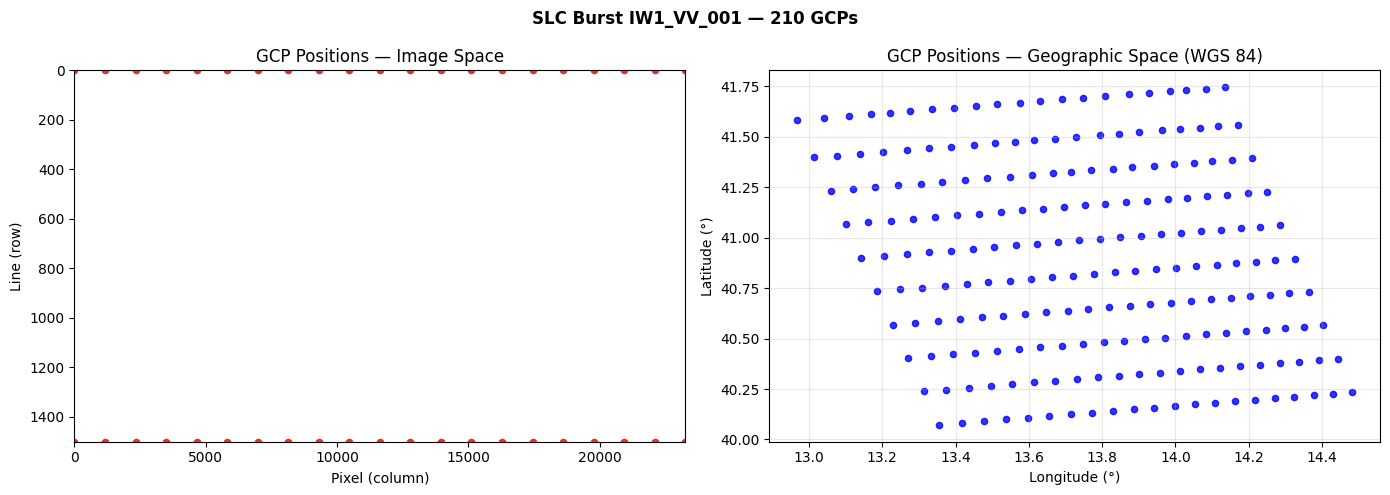

In [5]:
pixels = [gcp.GCPPixel for gcp in gcps]
lines = [gcp.GCPLine for gcp in gcps]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image space
axes[0].scatter(pixels, lines, c="red", s=20, alpha=0.8)
axes[0].set_xlim(0, ds.RasterXSize)
axes[0].set_ylim(ds.RasterYSize, 0)
axes[0].set_xlabel("Pixel (column)")
axes[0].set_ylabel("Line (row)")
axes[0].set_title("GCP Positions — Image Space")
axes[0].set_aspect("auto")

# Geographic space
axes[1].scatter(lons, lats, c="blue", s=20, alpha=0.8)
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
axes[1].set_title("GCP Positions — Geographic Space (WGS 84)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"SLC Burst IW1_VV_001 — {gcp_count} GCPs", fontweight="bold")
plt.tight_layout()
plt.show()

(CoordTransform)=
## Pixel-to-Geographic Coordinate Transformation

With GCPs attached, GDAL can transform between pixel/line coordinates and geographic
coordinates using a polynomial GCP transformer.


In [6]:
# Create a GCP-based transformer
transformer = gdal.Transformer(ds, None, ["METHOD=GCP_POLYNOMIAL", "MAX_GCP_ORDER=3"])

# Transform the four image corners to geographic coordinates
corners = [
    ("Top-Left", 0, 0),
    ("Top-Right", ds.RasterXSize, 0),
    ("Bottom-Left", 0, ds.RasterYSize),
    ("Bottom-Right", ds.RasterXSize, ds.RasterYSize),
]

print(f"{'Corner':<14} {'Pixel':>8} {'Line':>8} {'Lon':>10} {'Lat':>10}")
print("-" * 55)
for name, px, ln in corners:
    ok, result = transformer.TransformPoint(0, px, ln, 0)
    if ok:
        print(f"{name:<14} {px:>8} {ln:>8} {result[0]:>10.4f} {result[1]:>10.4f}")

transformer = None

Corner            Pixel     Line        Lon        Lat
-------------------------------------------------------
Top-Left              0        0    13.3555    40.0710
Top-Right         23261        0    14.4823    40.2318
Bottom-Left           0     1501    13.3135    40.2397
Bottom-Right      23261     1501    14.4423    40.4005


(WarpProjection)=
## Warp Burst to Geographic Projection

Using the GCPs, we can reproject the SLC amplitude to WGS 84. SLC data is complex-valued
(CFloat32); we compute amplitude for visualization.


Warped size:  512 x 142 px
Origin:       lon=13.3147  lat=40.3989
Pixel size:   0.002277° x 0.002277°


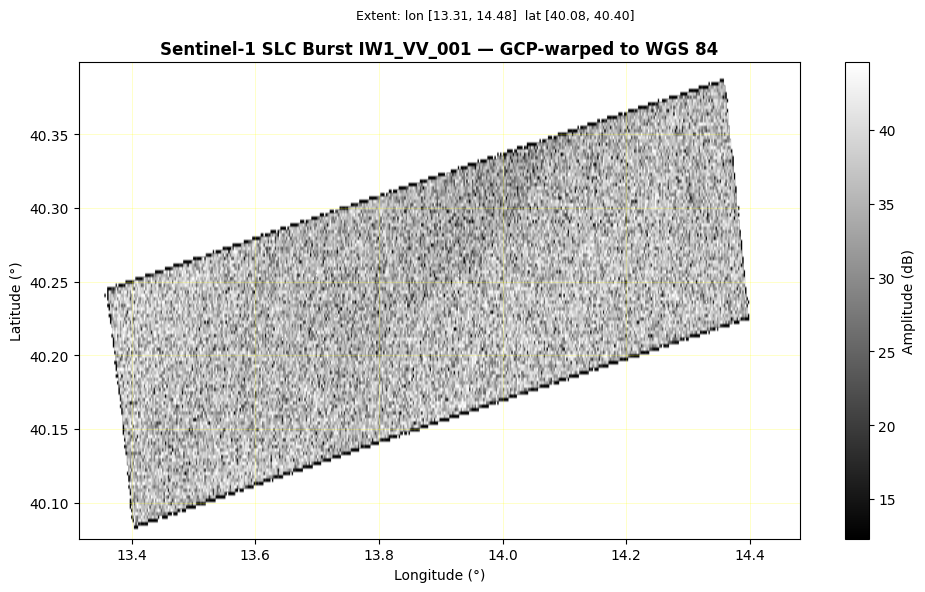

In [7]:
# Read the complex burst data and compute amplitude
raw = ds.GetRasterBand(1).ReadAsArray(buf_xsize=512, buf_ysize=0)
amplitude = np.abs(raw).astype(np.float32)

# Warp to WGS 84 using GCPs (reduced resolution to keep remote I/O fast)
warped = gdal.Warp(
    "",
    ds,
    format="MEM",
    dstSRS="EPSG:4326",
    width=512,
    height=0,
    resampleAlg="near",
    outputType=gdal.GDT_CFloat32,
)

assert warped is not None, "Warp failed"
gt = warped.GetGeoTransform()
print(f"Warped size:  {warped.RasterXSize} x {warped.RasterYSize} px")
print(f"Origin:       lon={gt[0]:.4f}  lat={gt[3]:.4f}")
print(f"Pixel size:   {gt[1]:.6f}° x {abs(gt[5]):.6f}°")

# Compute amplitude in dB for display
raw_warped = warped.GetRasterBand(1).ReadAsArray()
amp = np.abs(raw_warped).astype(np.float32)
amp_db = 20 * np.log10(np.where(amp > 0, amp, np.nan))

extent = [
    gt[0],
    gt[0] + gt[1] * warped.RasterXSize,
    gt[3] + gt[5] * warped.RasterYSize,
    gt[3],
]

fig, ax = plt.subplots(figsize=(10, 6))
vmin, vmax = np.nanpercentile(amp_db, [2, 98])
im = ax.imshow(amp_db, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="auto")
plt.colorbar(im, ax=ax, label="Amplitude (dB)")
ax.set_title(
    "Sentinel-1 SLC Burst IW1_VV_001 — GCP-warped to WGS 84", fontweight="bold"
)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.grid(True, alpha=0.3, color="yellow", linewidth=0.5)
plt.suptitle(
    f"Extent: lon [{extent[0]:.2f}, {extent[1]:.2f}]  lat [{extent[2]:.2f}, {extent[3]:.2f}]",
    fontsize=9,
)
plt.tight_layout()
plt.show()

warped = None

(CompareSubswaths)=
## Compare GCPs Across Subswaths

Each subswath (IW1, IW2, IW3) covers a different range of incidence angles and a different
geographic footprint. Let's check GCP counts and extents for the three VV bursts.


Burst                 Size         GCPs       Lon range             Lat range      
----------------------------------------------------------------------------------
IW1_VV_001         23261x1501       210     [12.97, 14.48]        [40.07, 41.75]   
IW2_VV_001         27012x1511       210     [13.98, 15.49]        [40.27, 41.93]   
IW3_VV_001         25954x1516       210     [14.99, 16.36]        [40.47, 42.10]   


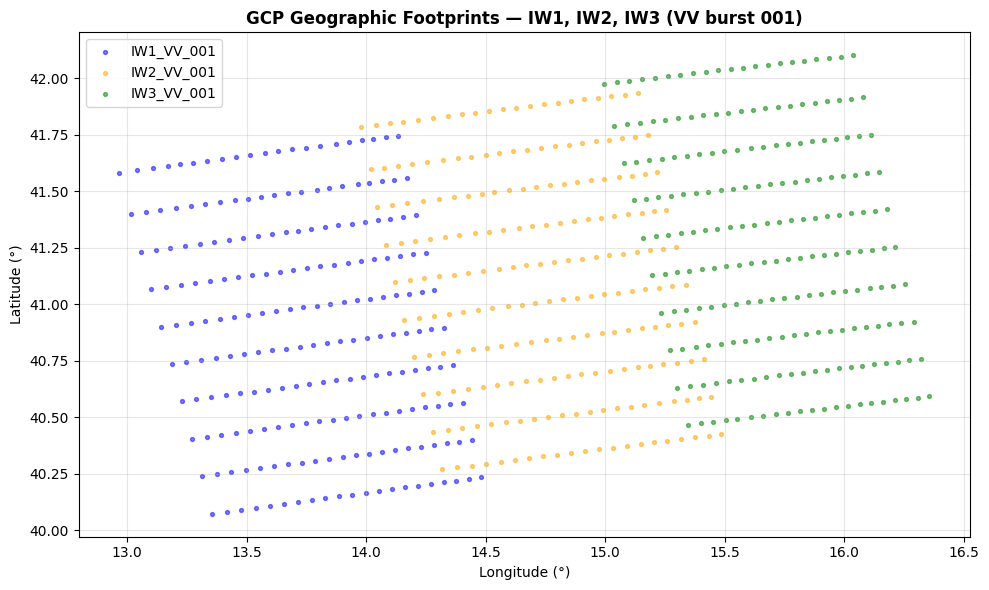

In [10]:
bursts = ["IW1_VV_001", "IW2_VV_001", "IW3_VV_001"]

print(f"{'Burst':<14} {'Size':^18} {'GCPs':>5}  {'Lon range':^20}  {'Lat range':^20}")
print("-" * 82)

burst_extents = {}
for burst_name in bursts:
    ds_b = gdal.OpenEx(zarr_path, gdal.OF_RASTER, open_options=[f"BURST={burst_name}"])
    if ds_b is None:
        print(f"{burst_name:<14}  NOT FOUND")
        continue
    gcps_b = ds_b.GetGCPs()
    n = len(gcps_b)
    lons_b = [g.GCPX for g in gcps_b]
    lats_b = [g.GCPY for g in gcps_b]
    size_str = f"{ds_b.RasterXSize}x{ds_b.RasterYSize}"
    lon_str = f"[{min(lons_b):.2f}, {max(lons_b):.2f}]"
    lat_str = f"[{min(lats_b):.2f}, {max(lats_b):.2f}]"
    print(f"{burst_name:<14} {size_str:^18} {n:>5}  {lon_str:^20}  {lat_str:^20}")
    burst_extents[burst_name] = (lons_b, lats_b)
    ds_b = None

# Plot geographic footprints of all three bursts
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"IW1_VV_001": "blue", "IW2_VV_001": "orange", "IW3_VV_001": "green"}
for burst_name, (lons_b, lats_b) in burst_extents.items():
    ax.scatter(
        lons_b,
        lats_b,
        s=8,
        alpha=0.5,
        label=burst_name,
        color=colors.get(burst_name, "gray"),
    )

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(
    "GCP Geographic Footprints — IW1, IW2, IW3 (VV burst 001)", fontweight="bold"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


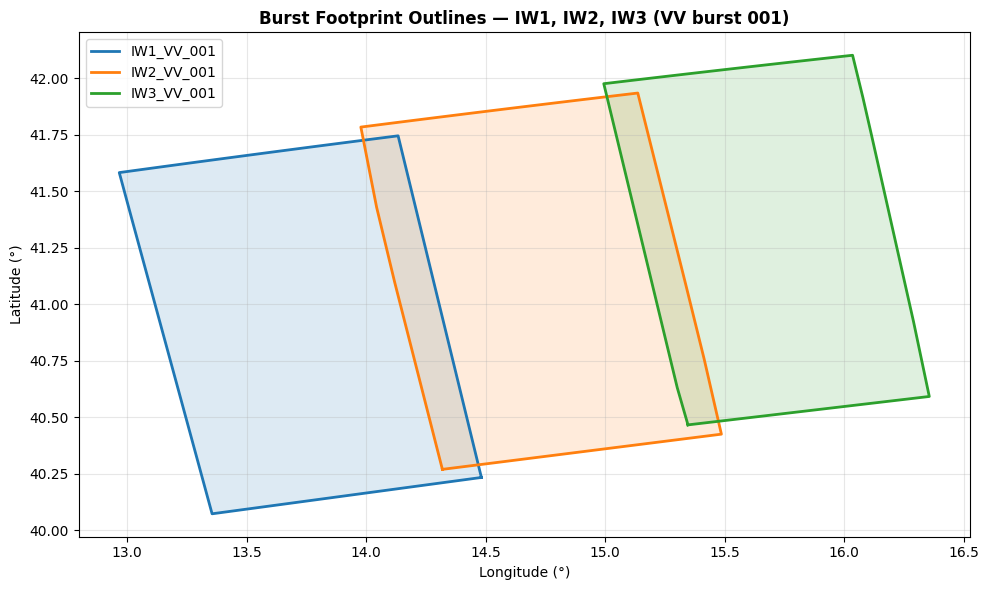

In [11]:
from scipy.spatial import ConvexHull

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor("#c8d8e8")  # ocean fallback

try:
    import geopandas as gpd

    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
    world.plot(ax=ax, color="#e8e0d0", edgecolor="gray", linewidth=0.5)
except Exception:
    pass  # plain ocean background is fine

colors = {
    "IW1_VV_001": "tab:blue",
    "IW2_VV_001": "tab:orange",
    "IW3_VV_001": "tab:green",
}

for burst_name, (lons_b, lats_b) in burst_extents.items():
    pts = np.column_stack([lons_b, lats_b])
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])
    color = colors.get(burst_name, "gray")
    ax.fill(hull_pts[:, 0], hull_pts[:, 1], alpha=0.4, color=color, label=burst_name)
    ax.plot(hull_pts[:, 0], hull_pts[:, 1], color=color, linewidth=2)

# Auto-zoom to scene region with margin
all_lons = [lon for lons_b, _ in burst_extents.values() for lon in lons_b]
all_lats = [lat for _, lats_b in burst_extents.values() for lat in lats_b]
margin = 3
ax.set_xlim(min(all_lons) - margin, max(all_lons) + margin)
ax.set_ylim(min(all_lats) - margin, max(all_lats) + margin)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Burst Footprints — IW1, IW2, IW3 (VV burst 001)", fontweight="bold")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.suptitle(
    f"lon [{min(all_lons):.2f}, {max(all_lons):.2f}]  "
    f"lat [{min(all_lats):.2f}, {max(all_lats):.2f}]",
    fontsize=9,
)
plt.tight_layout()
plt.show()

(CommandLine)=
## Command Line Usage

GCPs are visible via `gdalinfo` when you open a specific burst subdataset.


In [9]:
print("Inspect GCPs on an SLC burst:\n")
print(f"  gdalinfo \"EOPFZARR:'{SLC_URL}'\" -oo BURST=IW1_VV_001\n")

print("Warp burst to WGS 84:\n")
print(
    f"  gdalwarp -t_srs EPSG:4326 -ts 512 0 \\\n"
    f"    \"EOPFZARR:'{SLC_URL}' -oo BURST=IW1_VV_001\" \\\n"
    f"    output_burst_wgs84.tif\n"
)

Inspect GCPs on an SLC burst:

  gdalinfo "EOPFZARR:'/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v262/S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr'" -oo BURST=IW1_VV_001

Warp burst to WGS 84:

  gdalwarp -t_srs EPSG:4326 -ts 512 0 \
    "EOPFZARR:'/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v262/S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr' -oo BURST=IW1_VV_001" \
    output_burst_wgs84.tif



(Summary)=
## Summary

### GCP Geolocation on SLC Bursts

| Feature | Description |
|---------|-------------|
| **Automatic Extraction** | GCPs read from `conditions/gcp/` arrays (pixel, line, latitude, longitude, height) |
| **Burst Access** | Use `BURST=IW1_VV_001` open option to select a specific burst |
| **GCP SRS** | WGS 84 (EPSG:4326) with traditional GIS axis ordering (lon, lat) |
| **Reprojection** | `gdal.Warp()` uses GCPs via polynomial transformer |
| **Per-Subswath** | Each of IW1/IW2/IW3 has its own GCP grid with distinct geographic extent |

### Related Notebooks

- [Sentinel-1 SLC Burst Selection](GDAL_Sentinel-1_SLC_Burst_Selection.ipynb) — burst structure, amplitude, polarization comparison
- [Sentinel-1 GRD GCP Geolocation](GDAL_Sentinel-1_GCP_Geolocation.ipynb) — equivalent GCP workflow for GRD products


(Cleanup)=
## Cleanup


In [ ]:
ds = None
print("All datasets closed")